In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Dataset Importing

In [2]:
df = pd.read_csv('Obesity Classification.csv')

In [3]:
df.sample(10)

,ID,Age,Gender,Height,Weight,BMI,Label
66,69,56,Male,210,95,27.0,Overweight
58,61,16,Male,175,55,21.2,Normal Weight
97,100,32,Male,190,25,10.0,Underweight
71,74,30,Female,150,40,16.7,Underweight
72,75,35,Male,190,65,22.7,Normal Weight
98,101,37,Female,140,25,10.0,Underweight
25,27,93,Female,140,40,16.7,Underweight
36,39,59,Male,210,115,30.8,Obese
69,72,20,Female,160,30,13.3,Underweight
27,29,103,Female,130,30,13.3,Underweight


df.info

## Handling Null Values

In [4]:
df.isnull().sum()

ID        0
Age       0
Gender    0
Height    0
Weight    0
BMI       0
Label     0
dtype: int64

## Handling duplicate values

In [5]:
df.duplicated().sum()

np.int64(0)

## Data Distribution

In [6]:
df['Label'].value_counts()

Label
Underweight      47
Normal Weight    29
Overweight       20
Obese            12
Name: count, dtype: int64

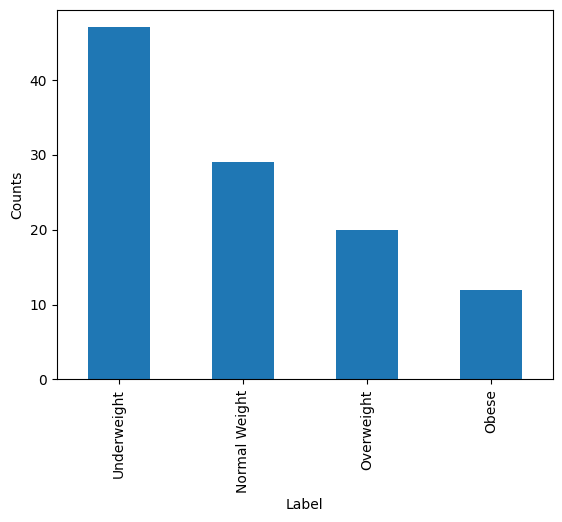

In [7]:
df['Label'].value_counts().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Counts')
plt.show()

# Encoding 

In [8]:
le = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])

In [9]:
oe = OneHotEncoder(sparse_output = False,drop='first')
df[['Gender']] = oe.fit_transform(df[['Gender']] )

In [10]:
df

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,1.0,175,80,25.3,0
1,2,30,0.0,160,60,22.5,0
2,3,35,1.0,180,90,27.3,2
3,4,40,0.0,150,50,20.0,3
4,5,45,1.0,190,100,31.2,1
...,...,...,...,...,...,...,...
103,106,11,1.0,175,10,3.9,3
104,107,16,0.0,160,10,3.9,3
105,108,21,1.0,180,15,5.6,3
106,109,26,0.0,150,15,5.6,3


## Seperating dependent and independent Variable

In [11]:
x= df.drop(columns=['Label'])

In [12]:
x

,ID,Age,Gender,Height,Weight,BMI
0,1,25,1.0,175,80,25.3
1,2,30,0.0,160,60,22.5
2,3,35,1.0,180,90,27.3
3,4,40,0.0,150,50,20.0
4,5,45,1.0,190,100,31.2
...,...,...,...,...,...,...
103,106,11,1.0,175,10,3.9
104,107,16,0.0,160,10,3.9
105,108,21,1.0,180,15,5.6
106,109,26,0.0,150,15,5.6


In [13]:
y = df["Label"]

In [14]:
y

0      0
1      0
2      2
3      3
4      1
      ..
103    3
104    3
105    3
106    3
107    3
Name: Label, Length: 108, dtype: int64

## Train Test Split

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

## Model Training

In [16]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predictions

In [17]:
y_pred = dt.predict(x_test)

## Model Evaluation

In [19]:
accuracy_score(y_test,y_pred)

0.9545454545454546